# Forecasting

This notebook develops a time-series forecast for synthetic monthly rideshare boardings.

## Objectives
- Build a forecasting-ready dataset
- Model monthly boardings with seasonality
- Compare historical actuals and fitted values
- Forecast the next 12 months
- Create a foundation for revenue and farebox recovery forecasting

In [2]:
# Import libraries for data handling, plotting, and forecasting.
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [3]:
# Set the project root path and load the modeling dataset.
project_root = Path.cwd().parent
df = pd.read_csv(project_root / "data" / "processed" / "rs_modeling_dataset.csv")

# Convert the date column to datetime and sort the data.
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

df.head()

,year_month,date,year,month,boardings,service_hours,revenue,total_cost,farebox_recovery,lag_1_boardings,lag_12_boardings,rolling_3m_boardings,rolling_3m_revenue
0,2020-01,2020-01-01,2020,1,8064.0,1242.0,33221.25,33735.08,0.9848,NaN,NaN,NaN,NaN
1,2020-02,2020-02-01,2020,2,7987.0,1305.0,32599.67,35452.52,0.9195,8064.0,NaN,NaN,NaN
2,2020-03,2020-03-01,2020,3,8596.0,1274.0,36173.09,34232.03,1.0567,7987.0,NaN,8215.666667,33998.003333
3,2020-04,2020-04-01,2020,4,3995.0,1135.0,16831.57,38048.23,0.4424,8596.0,NaN,6859.333333,28534.776667
4,2020-05,2020-05-01,2020,5,3080.0,1151.0,11991.75,30912.85,0.3879,3995.0,NaN,5223.666667,21665.470000


In [4]:
# Keep the key fields needed for the boarding forecast.
forecast_df = df[["date", "boardings"]].copy()

# Set the date as the index for time-series modeling.
forecast_df = forecast_df.set_index("date")

forecast_df.head()

,boardings
date,
2020-01-01,8064.0
2020-02-01,7987.0
2020-03-01,8596.0
2020-04-01,3995.0
2020-05-01,3080.0


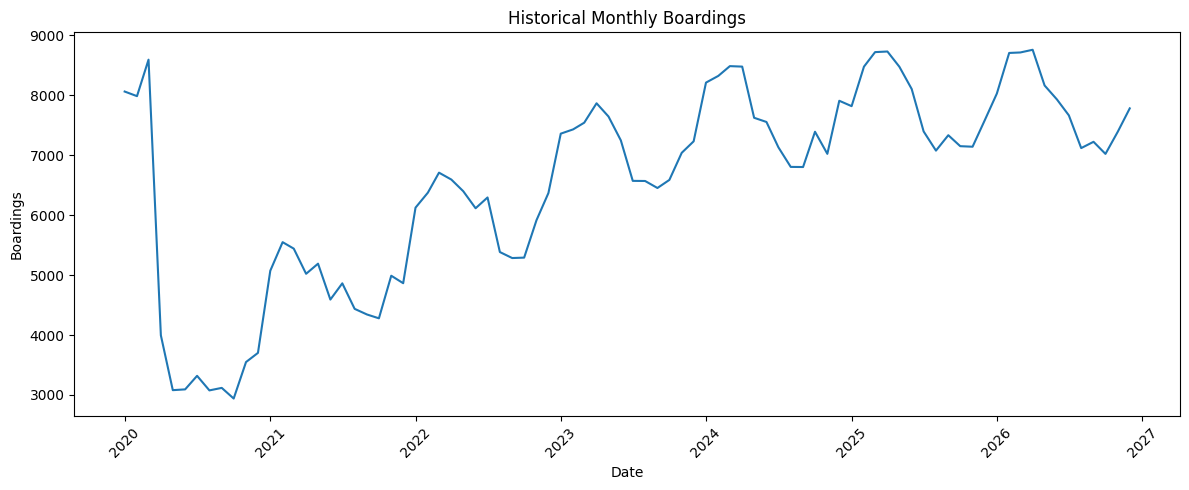

In [5]:
# Plot historical monthly boardings to inspect the overall pattern.
plt.figure(figsize=(12, 5))
plt.plot(forecast_df.index, forecast_df["boardings"])
plt.title("Historical Monthly Boardings")
plt.xlabel("Date")
plt.ylabel("Boardings")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [6]:
# Fit a seasonal SARIMAX model to monthly boardings.
# The seasonal period is set to 12 to reflect yearly seasonality in monthly data.
model = SARIMAX(
    forecast_df["boardings"],
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

results = model.fit(disp=False)

# Print model summary.
results.summary()

/Users/ashwinphilip/Transit-Rideshare-Analysis/.venv/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/ashwinphilip/Transit-Rideshare-Analysis/.venv/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/ashwinphilip/Transit-Rideshare-Analysis/.venv/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                          boardings   No. Observations:                   84
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -409.149
Date:                            Wed, 11 Mar 2026   AIC                            828.298
Time:                                    17:52:40   BIC                            838.514
Sample:                                01-01-2020   HQIC                           832.268
                                     - 12-01-2026                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2899      0.273     -1.061      0.289      -0.826       0.246
ma.L1         -3.1506      2.700     -1.167      0.243      -8.443       2.142
ar.S.L12       0.3871      0.053      7.301      0.000       0.283       0.491
ma.S.L12      -0.9809      3.559     -0.276      0.783      -7.956       5.994
sigma2      7347.0917   2.79e+04      0.263      0.793   -4.74e+04    6.21e+04
===================================================================================
Ljung-Box (L1) (Q):                   0.37   Jarque-Bera (JB):                 3.30
Prob(Q):                              0.54   Prob(JB):                         0.19
Heteroskedasticity (H):               0.48   Skew:                            -0.54
Prob(H) (two-sided):                  0.12   Kurtosis:                         3.49
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [7]:
# Generate fitted values for the historical period.
forecast_df["fitted_boardings"] = results.fittedvalues

forecast_df.head()

,boardings,fitted_boardings
date,,
2020-01-01,8064.0,0.000000
2020-02-01,7987.0,7284.639066
2020-03-01,8596.0,8100.139664
2020-04-01,3995.0,8481.539615
2020-05-01,3080.0,4767.298539


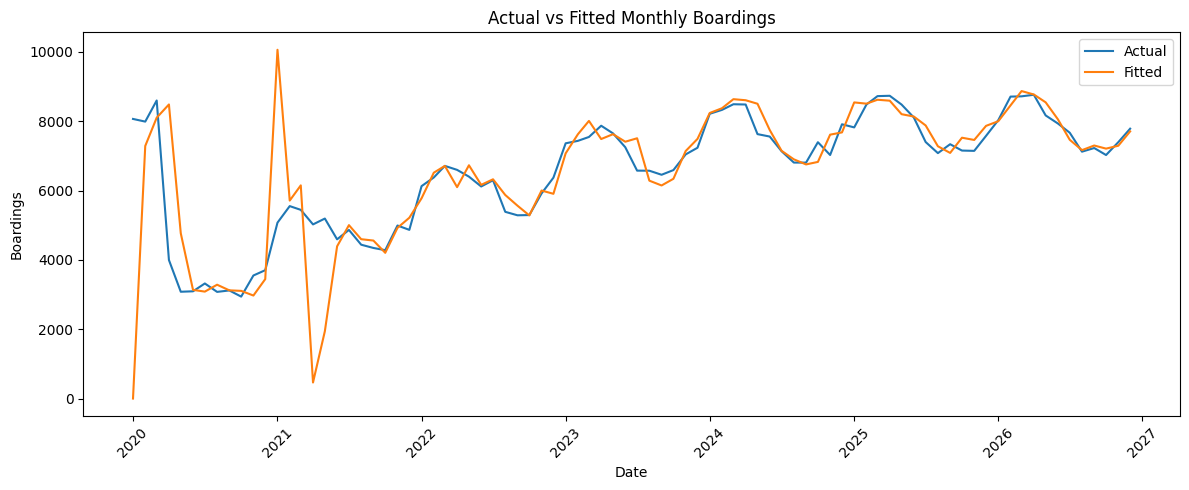

In [8]:
# Plot actual boardings against fitted values to evaluate model fit.
plt.figure(figsize=(12, 5))
plt.plot(forecast_df.index, forecast_df["boardings"], label="Actual")
plt.plot(forecast_df.index, forecast_df["fitted_boardings"], label="Fitted")
plt.title("Actual vs Fitted Monthly Boardings")
plt.xlabel("Date")
plt.ylabel("Boardings")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [14]:
# Define two forecast horizons:
# - 12 months for the main operational forecast
# - 24 months for a longer-term planning view
short_horizon = 12
long_horizon = 24

In [15]:
# Generate forecasts for both horizons.
short_forecast_obj = results.get_forecast(steps=short_horizon)
long_forecast_obj = results.get_forecast(steps=long_horizon)

# Extract forecasted mean values.
short_forecast_mean = short_forecast_obj.predicted_mean
long_forecast_mean = long_forecast_obj.predicted_mean

# Extract confidence intervals.
short_forecast_ci = short_forecast_obj.conf_int()
long_forecast_ci = long_forecast_obj.conf_int()

In [16]:
# Create future monthly dates for the 12-month forecast.
short_future_dates = pd.date_range(
    start=forecast_df.index.max() + pd.offsets.MonthBegin(1),
    periods=short_horizon,
    freq="MS"
)

# Build the 12-month forecast output table.
short_forecast_df = pd.DataFrame({
    "date": short_future_dates,
    "forecast_boardings": short_forecast_mean.values,
    "lower_ci": short_forecast_ci.iloc[:, 0].values,
    "upper_ci": short_forecast_ci.iloc[:, 1].values
})

short_forecast_df["year_month"] = short_forecast_df["date"].dt.strftime("%Y-%m")

short_forecast_df

,date,forecast_boardings,lower_ci,upper_ci,year_month
0,2027-01-01,8284.939525,7716.381498,8853.497551,2027-01
1,2027-02-01,8813.853103,8203.623110,9424.083096,2027-02
2,2027-03-01,8971.753495,8283.566591,9659.940399,2027-03
3,2027-04-01,8925.128409,8177.293845,9672.962972,2027-04
4,2027-05-01,8545.430067,7739.492241,9351.367894,2027-05
5,2027-06-01,8267.281118,7407.931834,9126.630402,2027-06
6,2027-07-01,7995.626449,7085.783672,8905.469226,2027-07
7,2027-08-01,7505.564575,6547.945394,8463.183755,2027-08
8,2027-09-01,7559.142110,6556.003135,8562.281084,2027-09
9,2027-10-01,7485.362197,6438.679415,8532.044978,2027-10


In [17]:
# Create future monthly dates for the 24-month forecast.
long_future_dates = pd.date_range(
    start=forecast_df.index.max() + pd.offsets.MonthBegin(1),
    periods=long_horizon,
    freq="MS"
)

# Build the 24-month forecast output table.
long_forecast_df = pd.DataFrame({
    "date": long_future_dates,
    "forecast_boardings": long_forecast_mean.values,
    "lower_ci": long_forecast_ci.iloc[:, 0].values,
    "upper_ci": long_forecast_ci.iloc[:, 1].values
})

long_forecast_df["year_month"] = long_forecast_df["date"].dt.strftime("%Y-%m")

long_forecast_df.head()

,date,forecast_boardings,lower_ci,upper_ci,year_month
0,2027-01-01,8284.939525,7716.381498,8853.497551,2027-01
1,2027-02-01,8813.853103,8203.623110,9424.083096,2027-02
2,2027-03-01,8971.753495,8283.566591,9659.940399,2027-03
3,2027-04-01,8925.128409,8177.293845,9672.962972,2027-04
4,2027-05-01,8545.430067,7739.492241,9351.367894,2027-05


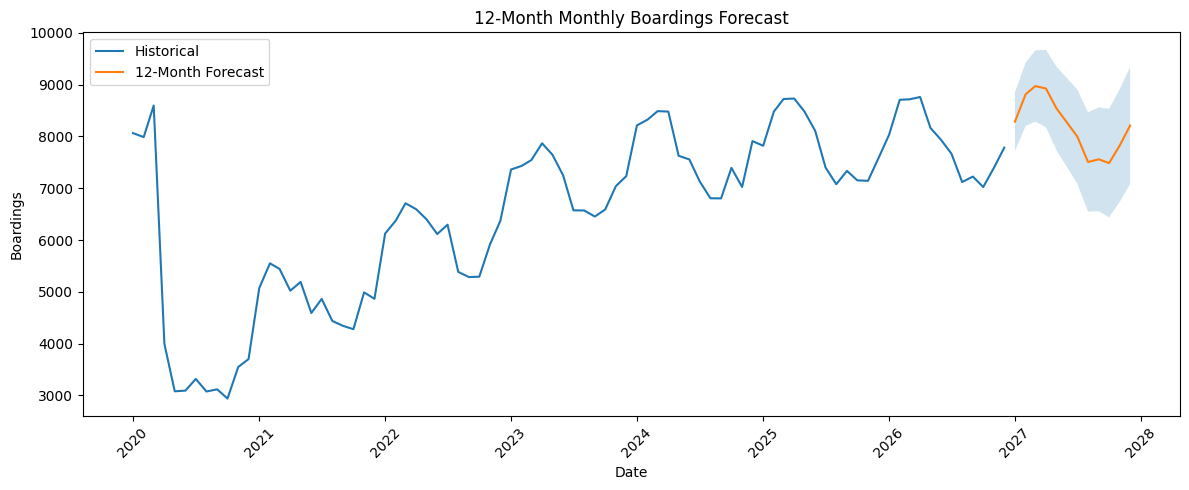

In [18]:
# Plot the main 12-month forecast.
plt.figure(figsize=(12, 5))

plt.plot(forecast_df.index, forecast_df["boardings"], label="Historical")
plt.plot(short_forecast_df["date"], short_forecast_df["forecast_boardings"], label="12-Month Forecast")

plt.fill_between(
    short_forecast_df["date"],
    short_forecast_df["lower_ci"],
    short_forecast_df["upper_ci"],
    alpha=0.2
)

plt.title("12-Month Monthly Boardings Forecast")
plt.xlabel("Date")
plt.ylabel("Boardings")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

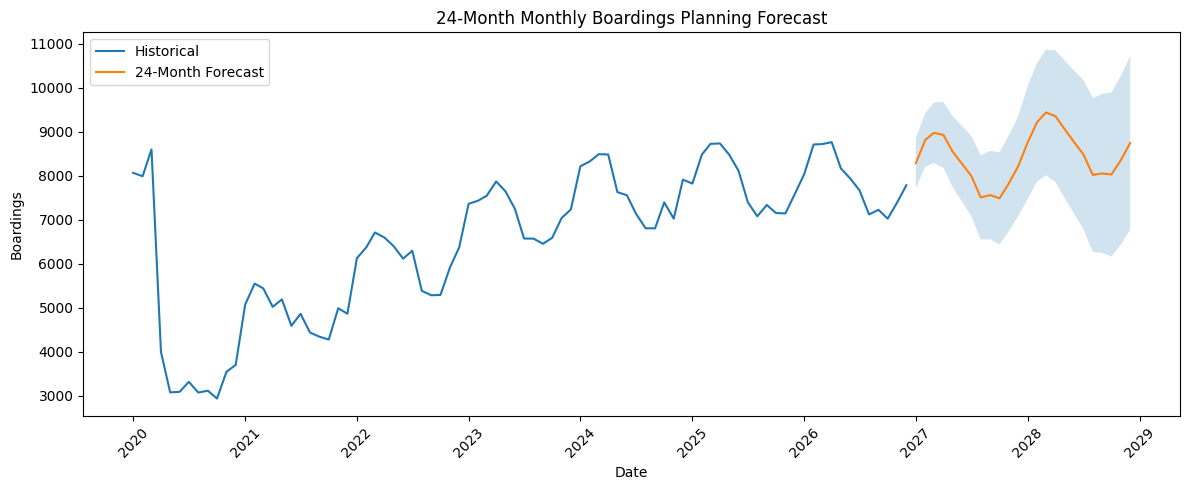

In [19]:
# Plot the 24-month planning forecast.
plt.figure(figsize=(12, 5))

plt.plot(forecast_df.index, forecast_df["boardings"], label="Historical")
plt.plot(long_forecast_df["date"], long_forecast_df["forecast_boardings"], label="24-Month Forecast")

plt.fill_between(
    long_forecast_df["date"],
    long_forecast_df["lower_ci"],
    long_forecast_df["upper_ci"],
    alpha=0.2
)

plt.title("24-Month Monthly Boardings Planning Forecast")
plt.xlabel("Date")
plt.ylabel("Boardings")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [20]:
# Save both forecast outputs to the processed data folder.
short_output_file = project_root / "data" / "processed" / "boardings_forecast_12m.csv"
long_output_file = project_root / "data" / "processed" / "boardings_forecast_24m.csv"

short_forecast_df.to_csv(short_output_file, index=False)
long_forecast_df.to_csv(long_output_file, index=False)

print(f"12-month forecast saved to: {short_output_file}")
print(f"24-month forecast saved to: {long_output_file}")

12-month forecast saved to: /Users/ashwinphilip/Transit-Rideshare-Analysis/data/processed/boardings_forecast_12m.csv
24-month forecast saved to: /Users/ashwinphilip/Transit-Rideshare-Analysis/data/processed/boardings_forecast_24m.csv


### Forecast Interpretation

- The 12-month forecast provides a near-term operational view of expected monthly boardings under current conditions.
- The 24-month forecast extends the outlook for planning purposes and shows how the seasonal pattern may continue if recent trends persist.
- Forecast uncertainty increases over longer horizons, so the 24-month projection should be interpreted as a directional planning estimate rather than a precise prediction.
- These boarding forecasts can be used as the starting point for projecting future revenue and farebox recovery.

In [25]:
# Create a copy of the full modeling dataset for business forecasting.
business_df = df.copy()

# Calculate recent average fare per boarding from the most recent 12 months.
recent_avg_fare = business_df["revenue"].tail(12).sum() / business_df["boardings"].tail(12).sum()

# Calculate recent average monthly growth in total cost using the last 12 months.
recent_cost_series = business_df["total_cost"].tail(12).reset_index(drop=True)
recent_cost_growth = recent_cost_series.pct_change().dropna().mean()

# Display the assumptions that will be used in the forecast.
recent_avg_fare, recent_cost_growth

(np.float64(4.146011870126848), np.float64(-0.0006085212023648454))

In [26]:
# Start from the recent average fare per boarding and allow only mild future fare growth.
# This keeps the revenue forecast realistic and avoids aggressive long-run improvement.
fare_growth_rate = 0.0015  # about 0.15% per month

short_forecast_df["projected_avg_fare"] = [
    recent_avg_fare * ((1 + fare_growth_rate) ** i)
    for i in range(1, len(short_forecast_df) + 1)
]

long_forecast_df["projected_avg_fare"] = [
    recent_avg_fare * ((1 + fare_growth_rate) ** i)
    for i in range(1, len(long_forecast_df) + 1)
]

short_forecast_df.head()

,date,forecast_boardings,lower_ci,upper_ci,year_month,projected_avg_fare
0,2027-01-01,8284.939525,7716.381498,8853.497551,2027-01,4.152231
1,2027-02-01,8813.853103,8203.623110,9424.083096,2027-02,4.158459
2,2027-03-01,8971.753495,8283.566591,9659.940399,2027-03,4.164697
3,2027-04-01,8925.128409,8177.293845,9672.962972,2027-04,4.170944
4,2027-05-01,8545.430067,7739.492241,9351.367894,2027-05,4.177200


In [27]:
# Forecast revenue using forecasted boardings and projected average fare.
short_forecast_df["forecast_revenue"] = (
    short_forecast_df["forecast_boardings"] * short_forecast_df["projected_avg_fare"]
).round(2)

long_forecast_df["forecast_revenue"] = (
    long_forecast_df["forecast_boardings"] * long_forecast_df["projected_avg_fare"]
).round(2)

short_forecast_df[["year_month", "forecast_boardings", "projected_avg_fare", "forecast_revenue"]].head()

,year_month,forecast_boardings,projected_avg_fare,forecast_revenue
0,2027-01,8284.939525,4.152231,34400.98
1,2027-02,8813.853103,4.158459,36652.05
2,2027-03,8971.753495,4.164697,37364.63
3,2027-04,8925.128409,4.170944,37226.21
4,2027-05,8545.430067,4.177200,35695.97


In [28]:
# Forecast total cost using the most recent observed monthly total cost
# and a modest monthly growth assumption based on recent history.
last_total_cost = business_df["total_cost"].iloc[-1]

short_forecast_df["forecast_total_cost"] = [
    last_total_cost * ((1 + recent_cost_growth) ** i)
    for i in range(1, len(short_forecast_df) + 1)
]

long_forecast_df["forecast_total_cost"] = [
    last_total_cost * ((1 + recent_cost_growth) ** i)
    for i in range(1, len(long_forecast_df) + 1)
]

short_forecast_df["forecast_total_cost"] = short_forecast_df["forecast_total_cost"].round(2)
long_forecast_df["forecast_total_cost"] = long_forecast_df["forecast_total_cost"].round(2)

short_forecast_df[["year_month", "forecast_total_cost"]].head()

,year_month,forecast_total_cost
0,2027-01,39390.87
1,2027-02,39366.90
2,2027-03,39342.94
3,2027-04,39319.00
4,2027-05,39295.07


In [29]:
# Calculate forecasted farebox recovery as forecasted revenue divided by forecasted total cost.
short_forecast_df["forecast_farebox_recovery"] = (
    short_forecast_df["forecast_revenue"] / short_forecast_df["forecast_total_cost"]
).round(3)

long_forecast_df["forecast_farebox_recovery"] = (
    long_forecast_df["forecast_revenue"] / long_forecast_df["forecast_total_cost"]
).round(3)

short_forecast_df[
    ["year_month", "forecast_revenue", "forecast_total_cost", "forecast_farebox_recovery"]
].head()

,year_month,forecast_revenue,forecast_total_cost,forecast_farebox_recovery
0,2027-01,34400.98,39390.87,0.873
1,2027-02,36652.05,39366.90,0.931
2,2027-03,37364.63,39342.94,0.950
3,2027-04,37226.21,39319.00,0.947
4,2027-05,35695.97,39295.07,0.908


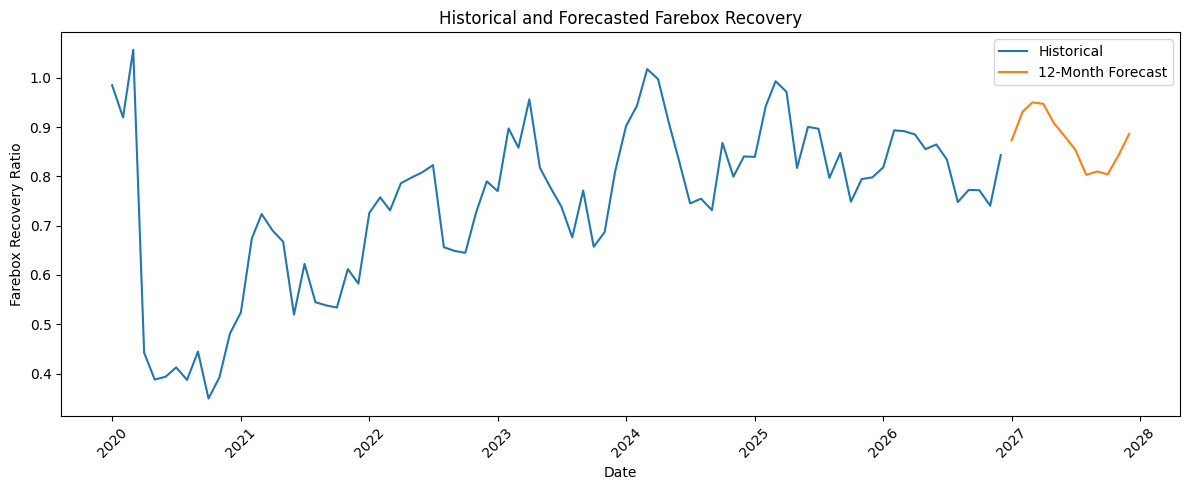

In [30]:
# Plot historical farebox recovery together with the 12-month forecast.
historical_farebox = business_df[["date", "farebox_recovery"]].copy()

plt.figure(figsize=(12, 5))
plt.plot(historical_farebox["date"], historical_farebox["farebox_recovery"], label="Historical")
plt.plot(short_forecast_df["date"], short_forecast_df["forecast_farebox_recovery"], label="12-Month Forecast")

plt.title("Historical and Forecasted Farebox Recovery")
plt.xlabel("Date")
plt.ylabel("Farebox Recovery Ratio")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

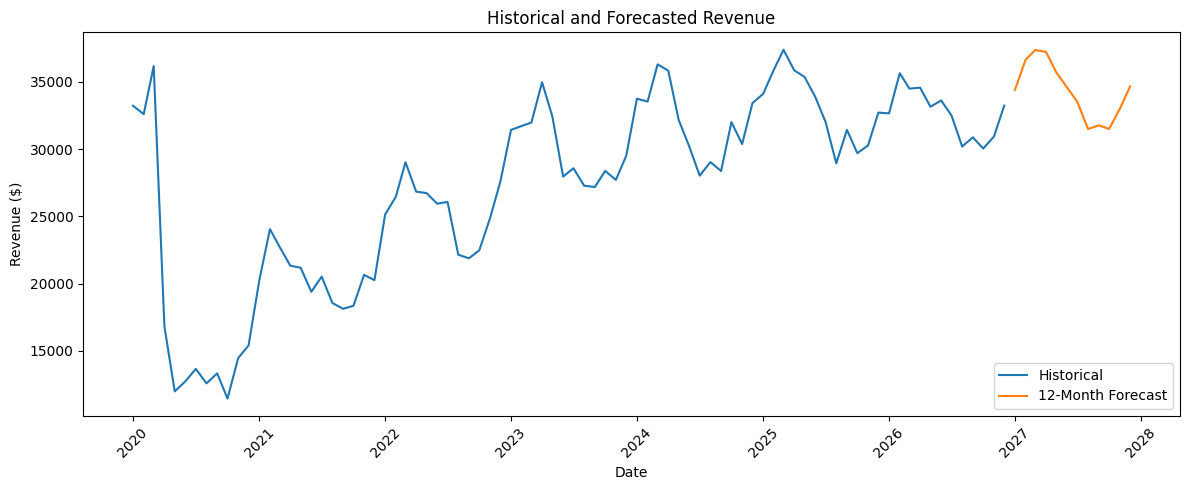

In [31]:
# Plot historical revenue together with the 12-month forecasted revenue.
historical_revenue = business_df[["date", "revenue"]].copy()

plt.figure(figsize=(12, 5))
plt.plot(historical_revenue["date"], historical_revenue["revenue"], label="Historical")
plt.plot(short_forecast_df["date"], short_forecast_df["forecast_revenue"], label="12-Month Forecast")

plt.title("Historical and Forecasted Revenue")
plt.xlabel("Date")
plt.ylabel("Revenue ($)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [32]:
# Create a final 12-month business forecast table with the most important projected metrics.
business_forecast_12m = short_forecast_df[
    [
        "year_month",
        "date",
        "forecast_boardings",
        "projected_avg_fare",
        "forecast_revenue",
        "forecast_total_cost",
        "forecast_farebox_recovery",
        "lower_ci",
        "upper_ci",
    ]
].copy()

business_forecast_12m.head()

,year_month,date,forecast_boardings,projected_avg_fare,forecast_revenue,forecast_total_cost,forecast_farebox_recovery,lower_ci,upper_ci
0,2027-01,2027-01-01,8284.939525,4.152231,34400.98,39390.87,0.873,7716.381498,8853.497551
1,2027-02,2027-02-01,8813.853103,4.158459,36652.05,39366.90,0.931,8203.623110,9424.083096
2,2027-03,2027-03-01,8971.753495,4.164697,37364.63,39342.94,0.950,8283.566591,9659.940399
3,2027-04,2027-04-01,8925.128409,4.170944,37226.21,39319.00,0.947,8177.293845,9672.962972
4,2027-05,2027-05-01,8545.430067,4.177200,35695.97,39295.07,0.908,7739.492241,9351.367894


In [34]:
# Round forecast output columns for cleaner presentation.
business_forecast_12m["forecast_boardings"] = business_forecast_12m["forecast_boardings"].round(0)
business_forecast_12m["projected_avg_fare"] = business_forecast_12m["projected_avg_fare"].round(2)
business_forecast_12m["forecast_revenue"] = business_forecast_12m["forecast_revenue"].round(2)
business_forecast_12m["forecast_total_cost"] = business_forecast_12m["forecast_total_cost"].round(2)
business_forecast_12m["forecast_farebox_recovery"] = business_forecast_12m["forecast_farebox_recovery"].round(3)
business_forecast_12m["lower_ci"] = business_forecast_12m["lower_ci"].round(0)
business_forecast_12m["upper_ci"] = business_forecast_12m["upper_ci"].round(0)

business_forecast_12m.head()

,year_month,date,forecast_boardings,projected_avg_fare,forecast_revenue,forecast_total_cost,forecast_farebox_recovery,lower_ci,upper_ci
0,2027-01,2027-01-01,8285.0,4.15,34400.98,39390.87,0.873,7716.0,8853.0
1,2027-02,2027-02-01,8814.0,4.16,36652.05,39366.90,0.931,8204.0,9424.0
2,2027-03,2027-03-01,8972.0,4.16,37364.63,39342.94,0.950,8284.0,9660.0
3,2027-04,2027-04-01,8925.0,4.17,37226.21,39319.00,0.947,8177.0,9673.0
4,2027-05,2027-05-01,8545.0,4.18,35695.97,39295.07,0.908,7739.0,9351.0


In [35]:
# Save the final 12-month business forecast output.
business_forecast_file = project_root / "data" / "processed" / "business_forecast_12m.csv"
business_forecast_12m.to_csv(business_forecast_file, index=False)

print(f"Business forecast saved to: {business_forecast_file}")

Business forecast saved to: /Users/ashwinphilip/Transit-Rideshare-Analysis/data/processed/business_forecast_12m.csv


### Business Forecast Interpretation

- Forecasted boardings provide the basis for projecting short-term service demand.
- Revenue is projected using forecasted boardings and a modest average fare growth assumption.
- Total cost is projected using the latest observed cost level and recent cost growth behavior.
- Forecasted farebox recovery translates the ridership forecast into a business performance outlook.
- This output provides a baseline forecast that can later be compared against pricing or cost-pressure scenarios.